# Model Performance Analysis & Hyperparameters

This notebook contains the analysis of the models' performances in terms of training and test set error, as well as an overview of their hyperparameters.

In [1]:
from configparser import ConfigParser
import yaml
import os
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from current_research_feature_effects.plotting.plots import boxplot_model_results

In [2]:
EXPERIMENT_NAME = "main_study"

os.chdir("..")

config = ConfigParser()
config.read(f"./experiments/{EXPERIMENT_NAME}/main_study.ini")

['./experiments/main_study/main_study.ini']

## Model Performances

In [4]:
model_results_storage = config.get("storage", "model_results")

with open(config.get("simulation_params", "datasets_yaml"), "r") as file:
    datasets_config = yaml.safe_load(file)
datasets = list(datasets_config.keys())
df = pd.DataFrame()
dfs = []
for dataset in datasets:
    df_temp = pd.read_sql_table(
        "model_a_results", f"sqlite:///experiments/{EXPERIMENT_NAME}/{dataset}{model_results_storage}"
    )
    df_temp["dataset"] = dataset
    df_temp = df_temp.sort_values(by=["dataset", "model", "sample_size", "simulation"])
    dfs.append(df_temp)
    df = pd.concat([df, df_temp]).drop(columns=["index"])

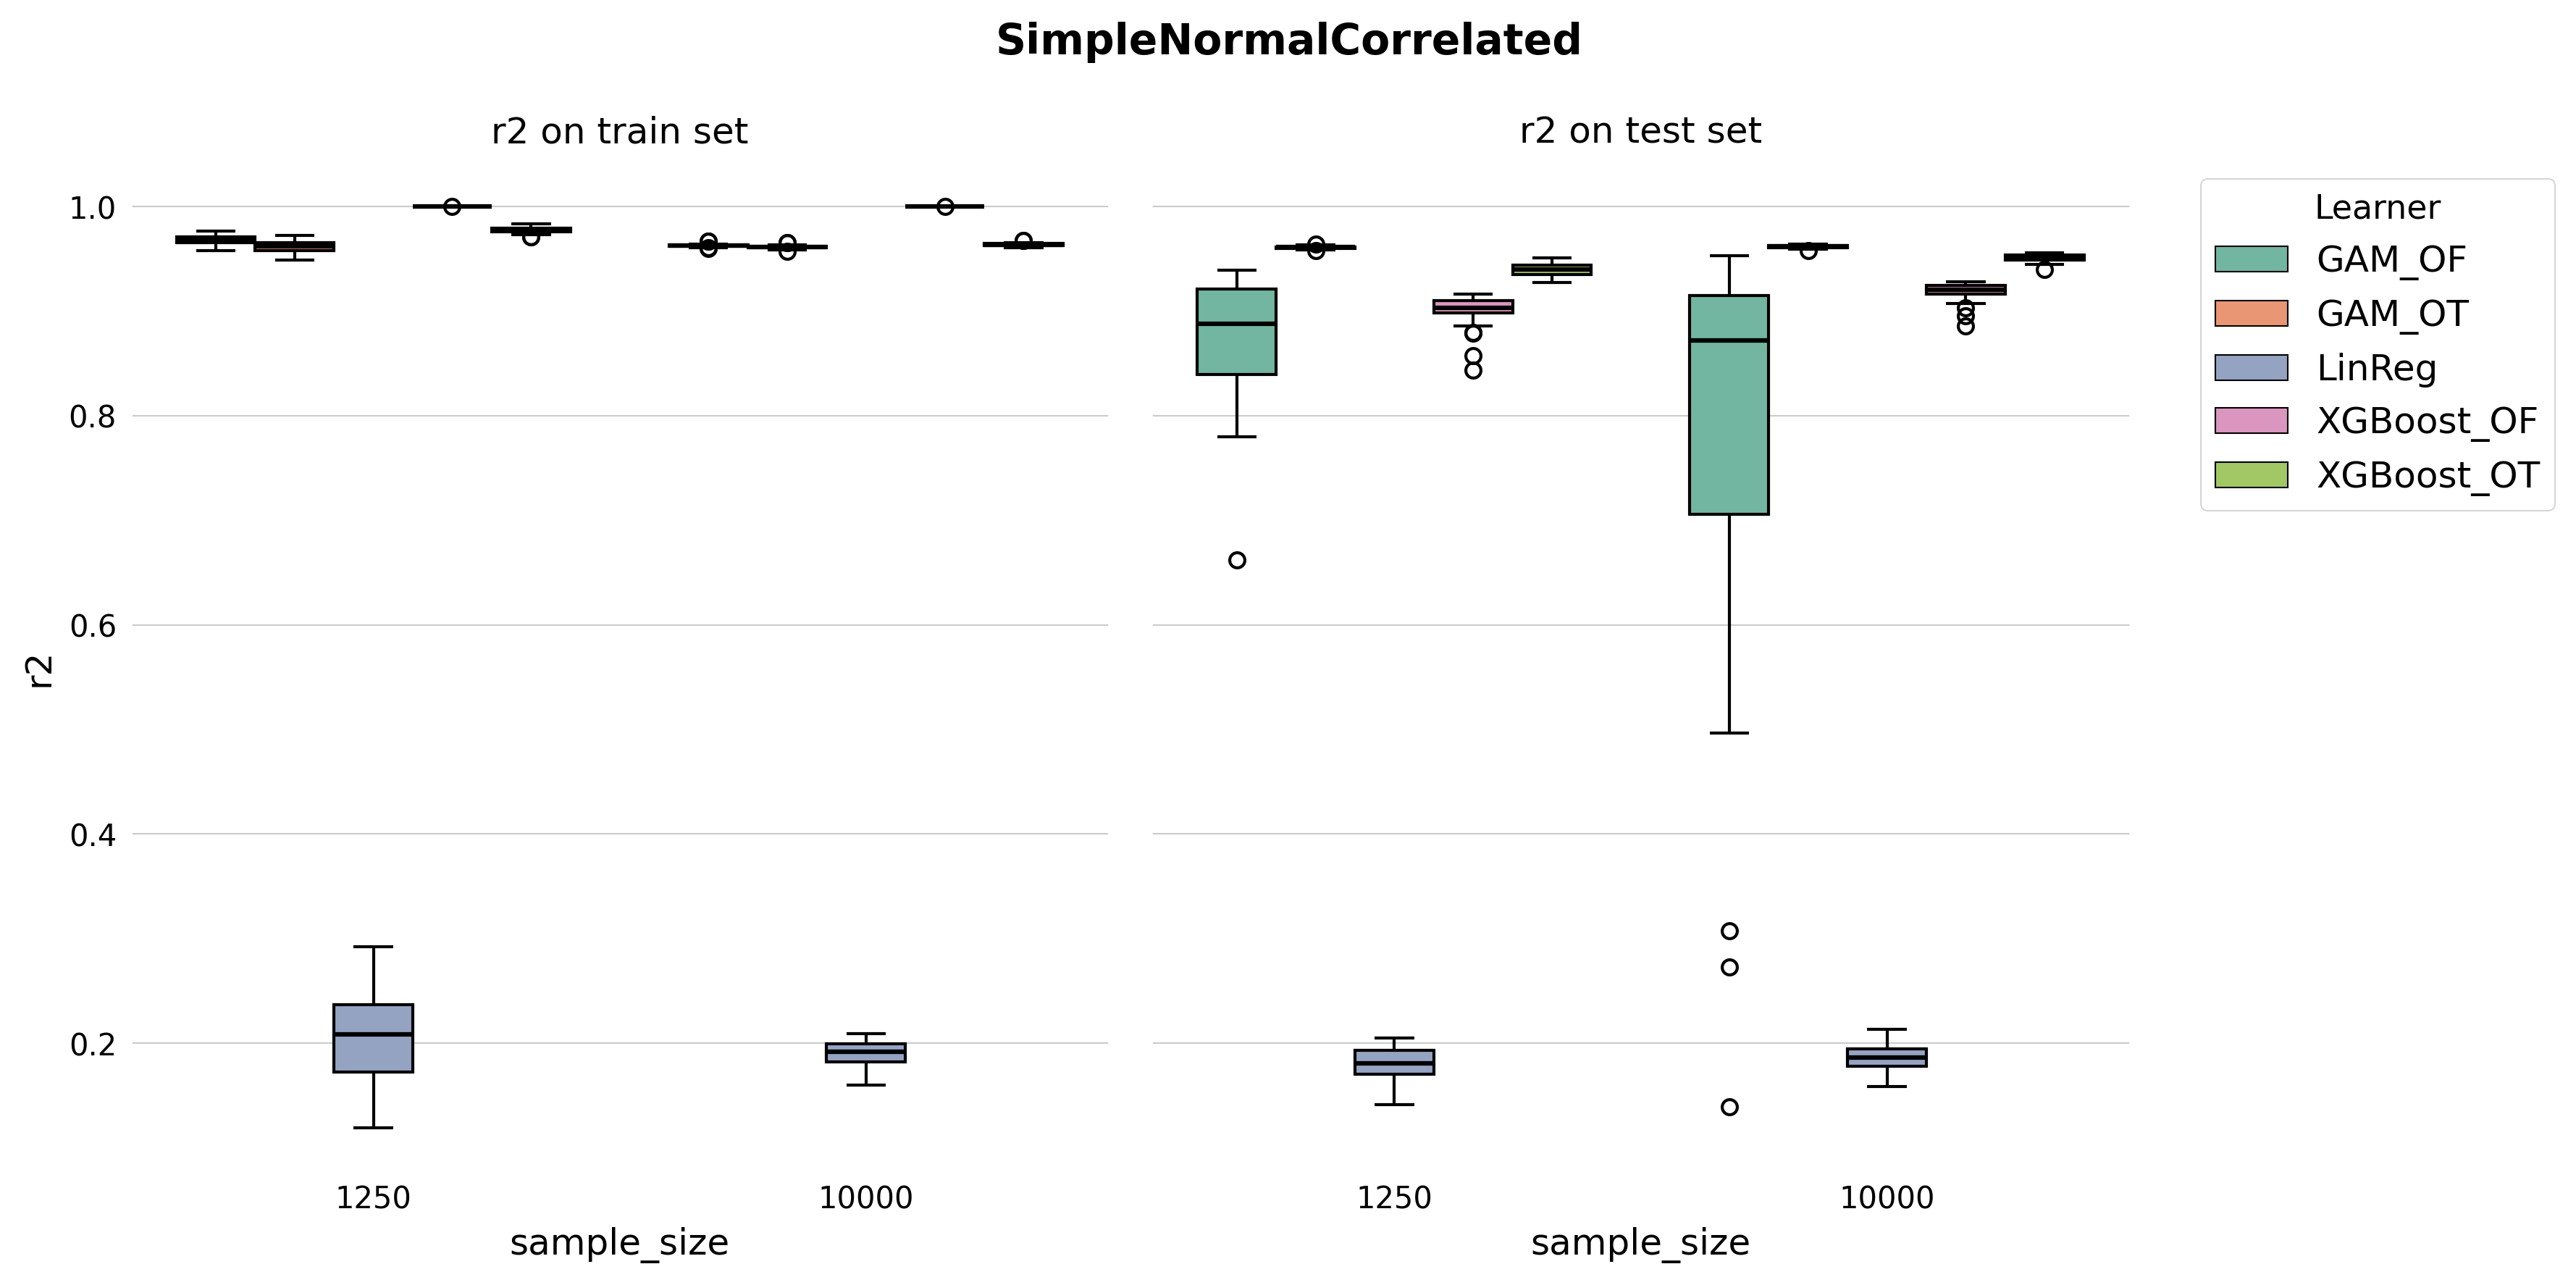

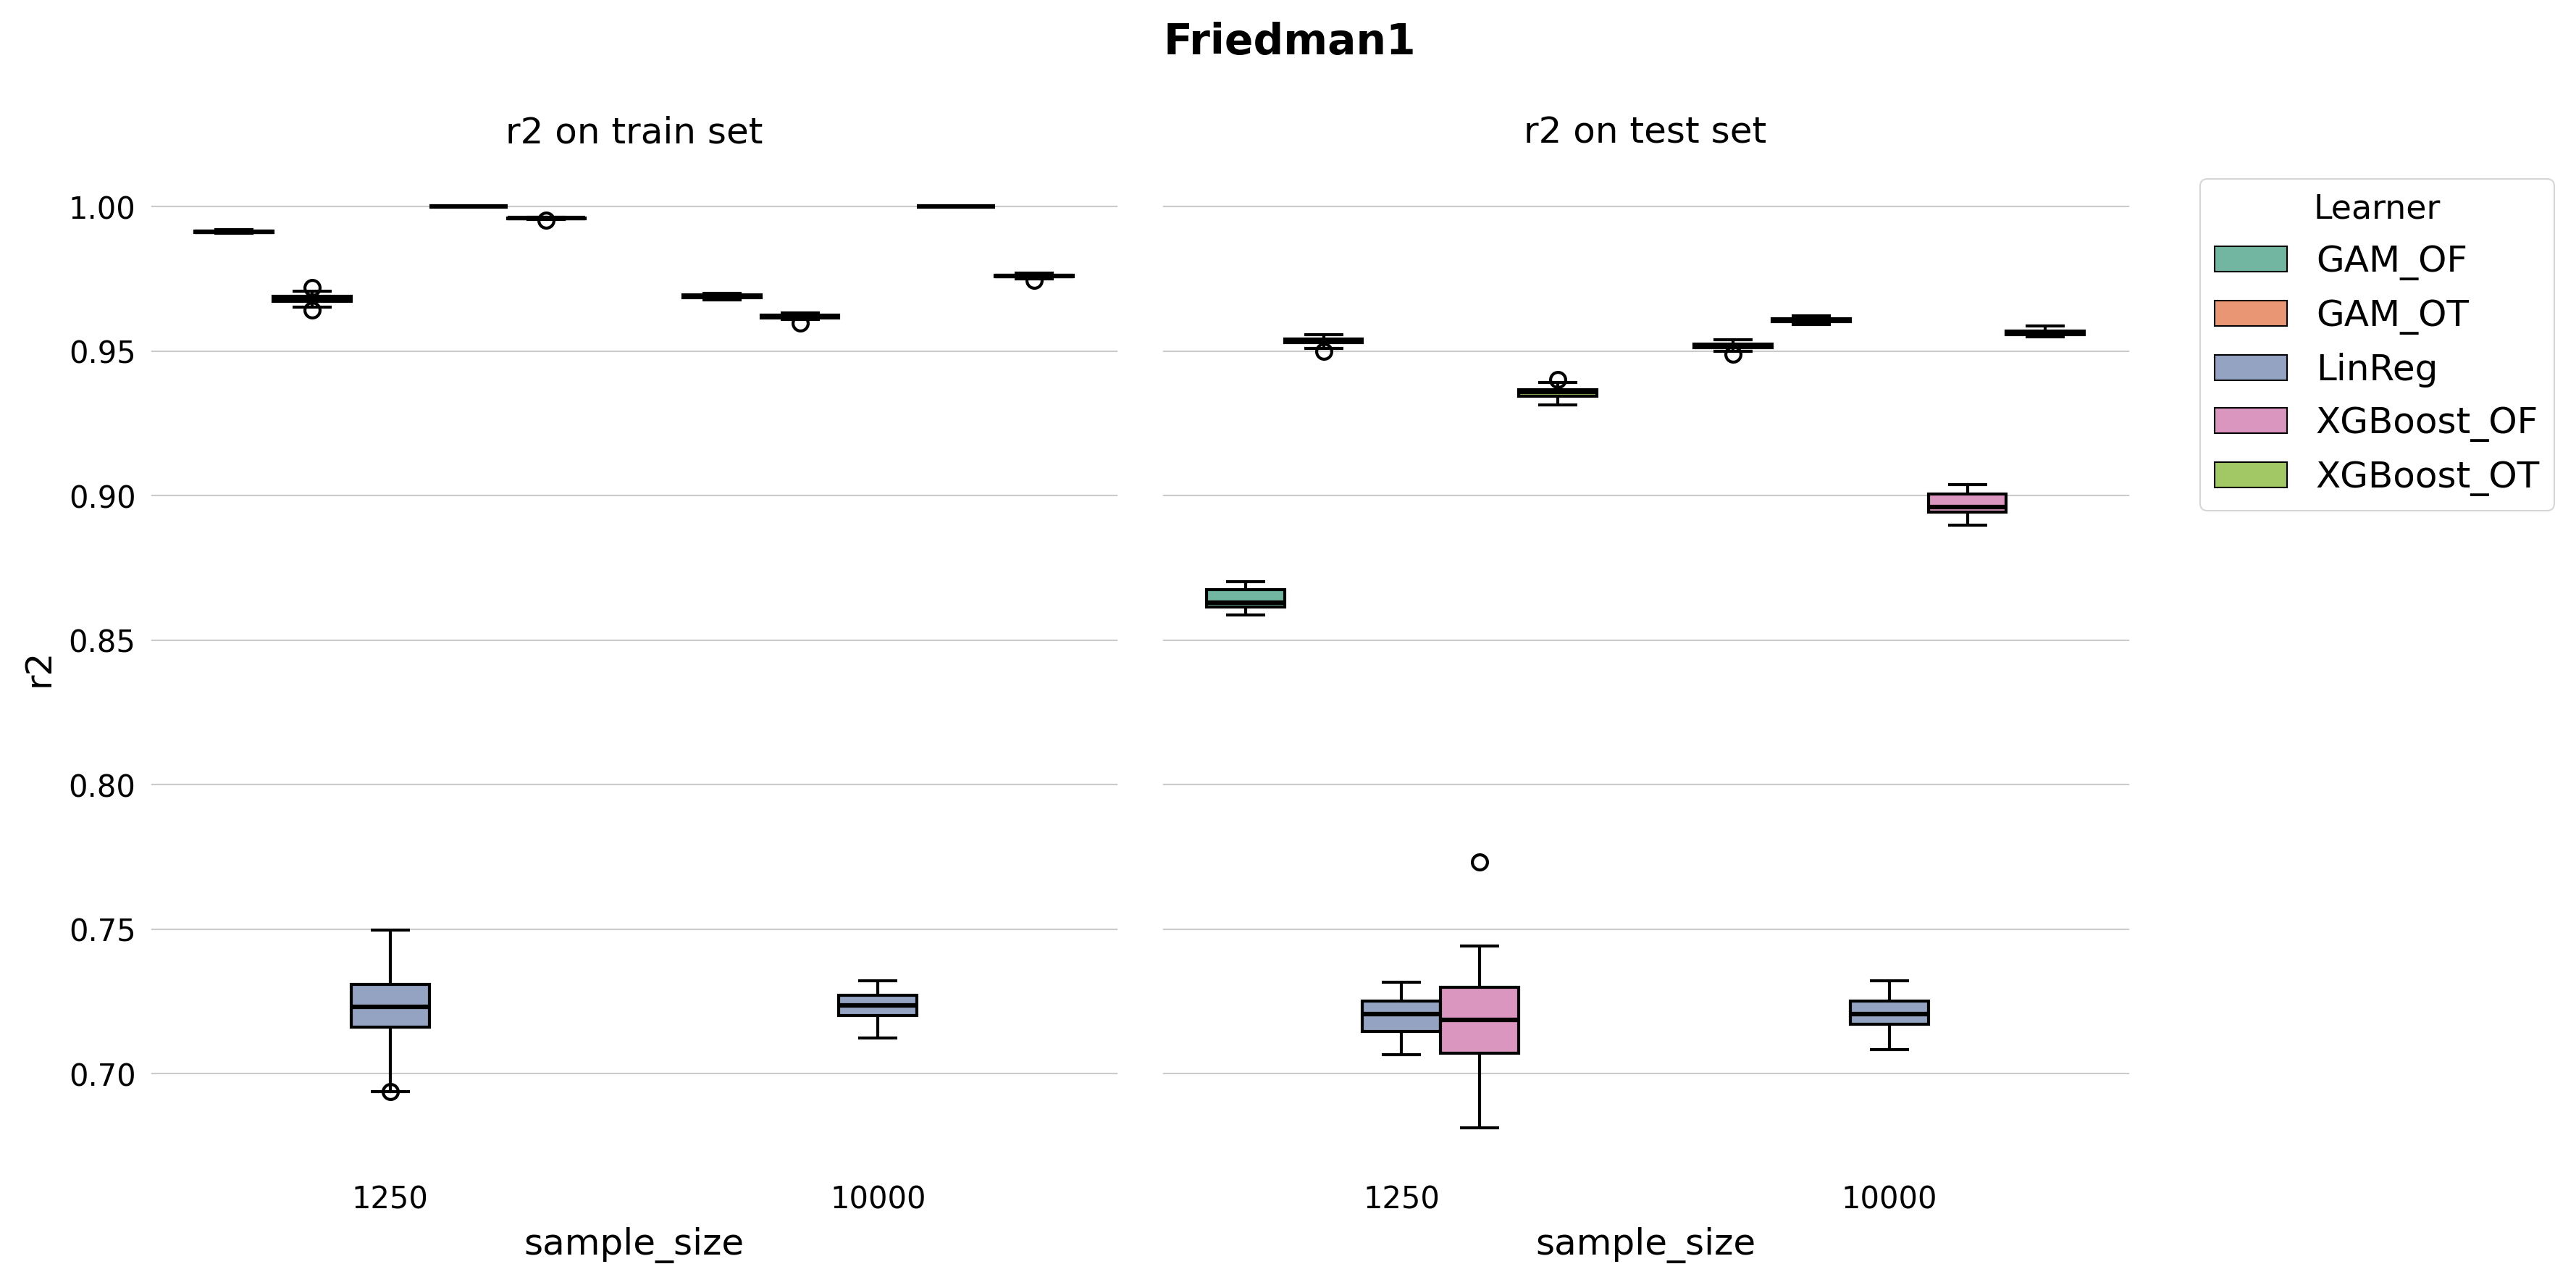

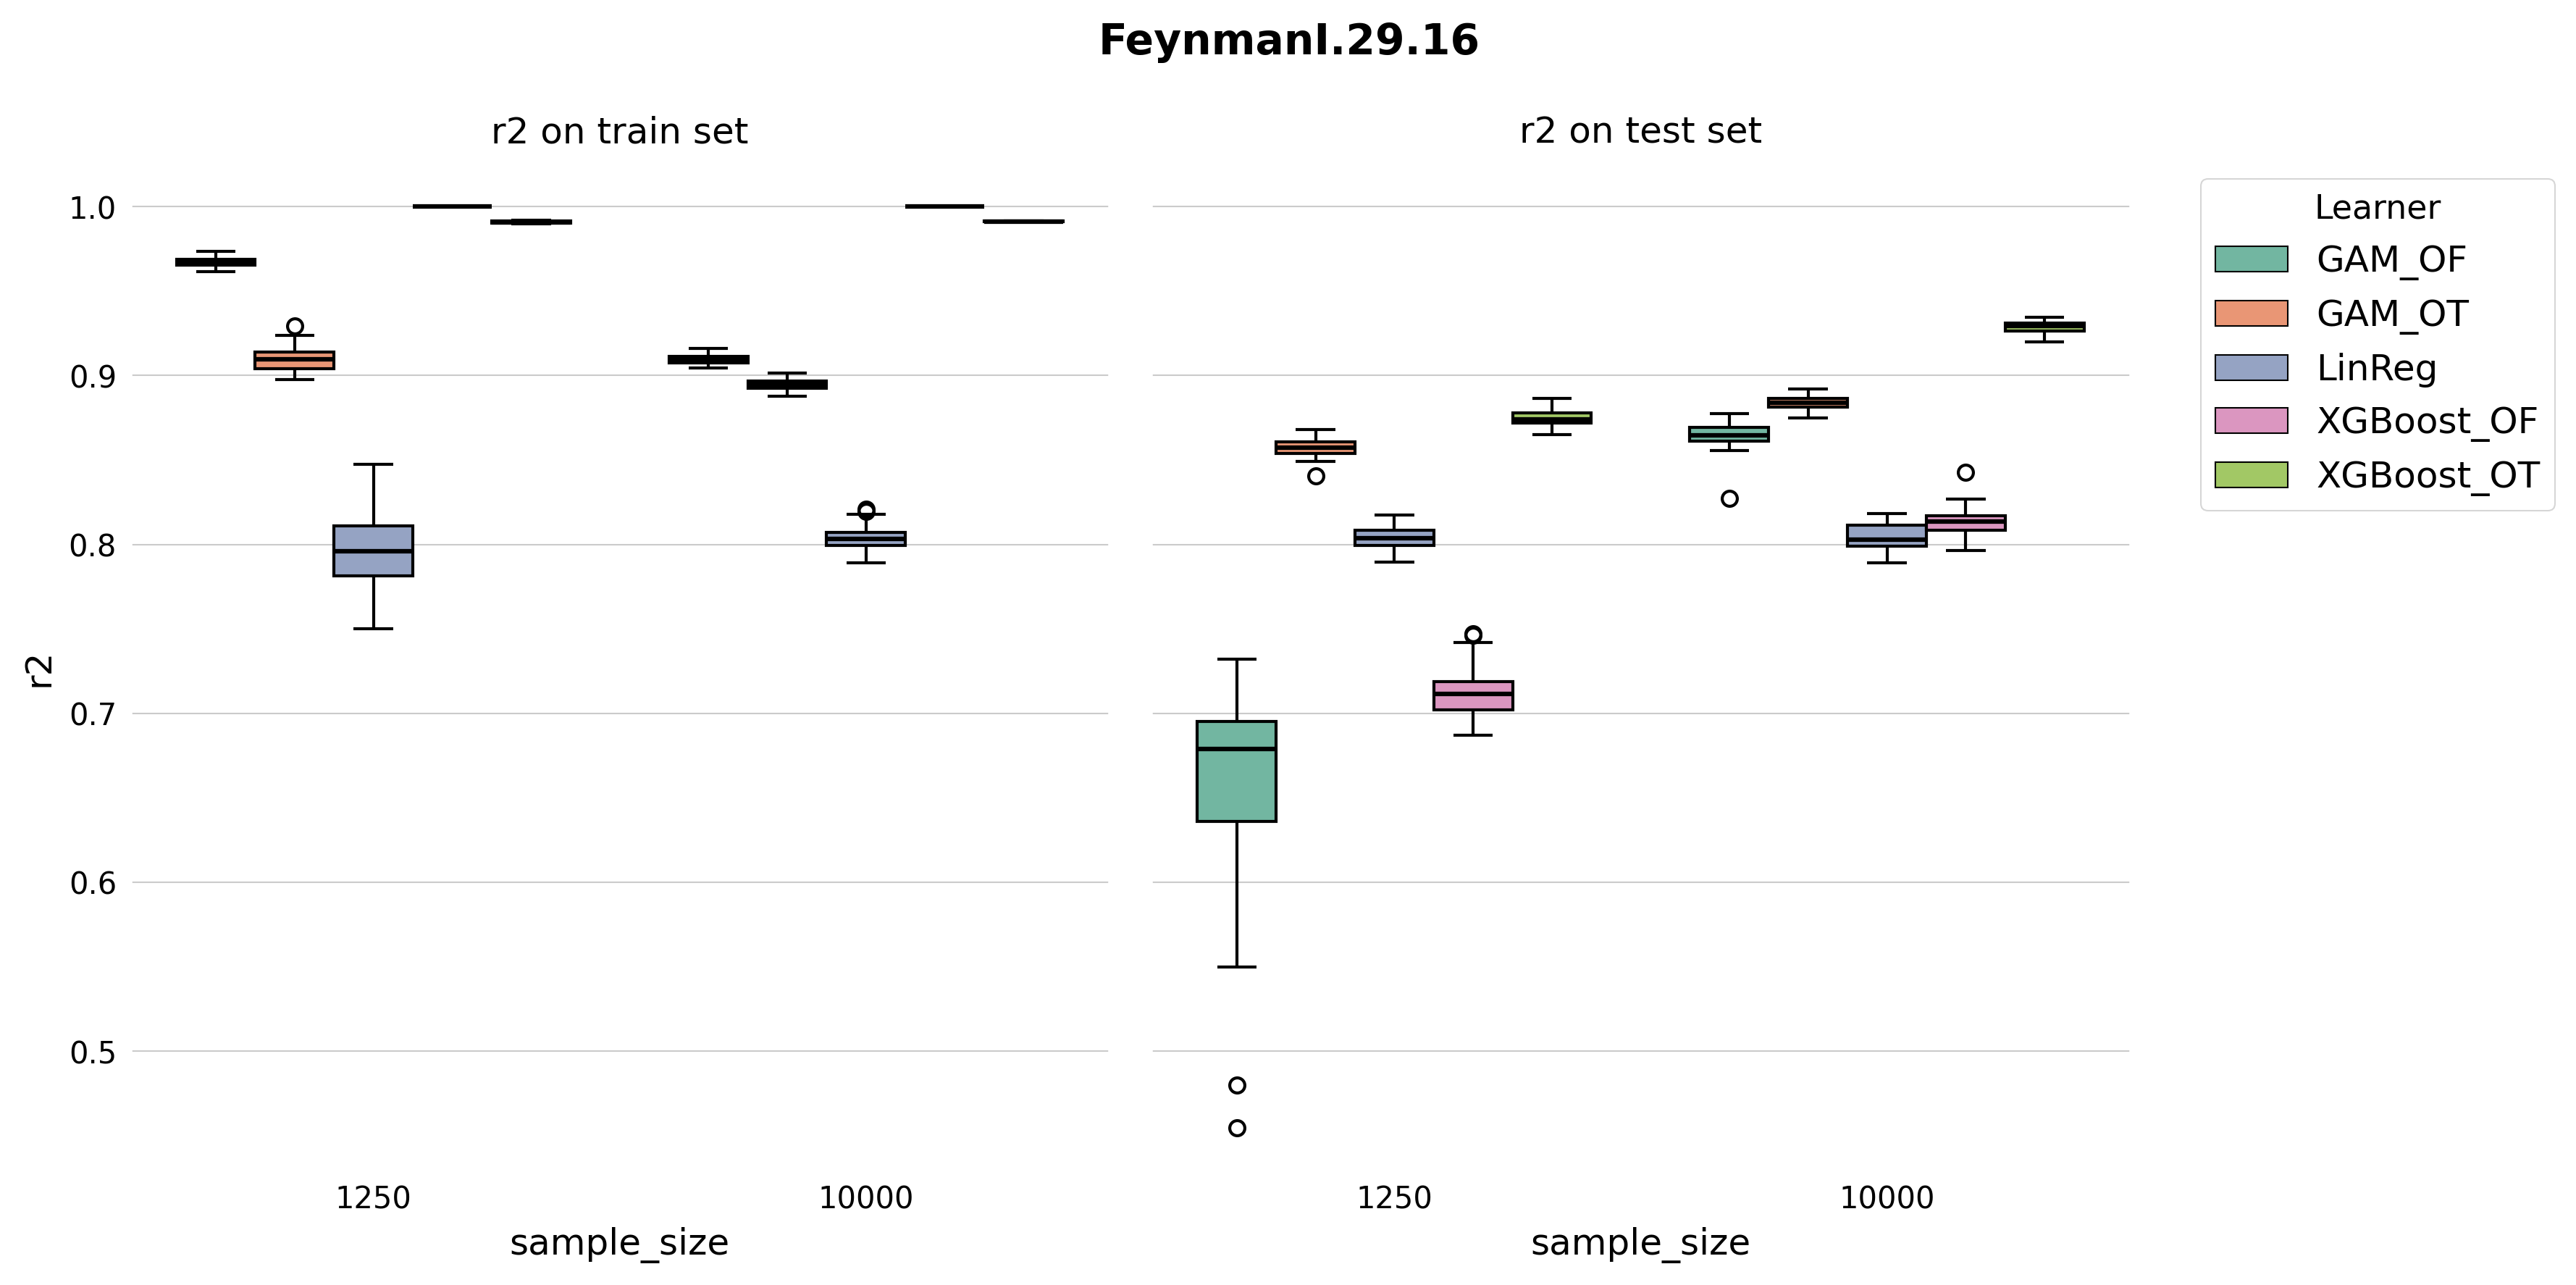

In [5]:
for df_, dataset in zip(dfs, datasets):
    boxplot_model_results(metric="r2", df=df_)  # , large_font=True
    plt.gcf().suptitle(dataset, fontsize=14, fontweight="bold")
    # plt.gcf().suptitle("")
    # plt.savefig(f"./paper/img/model_performance_{dataset}.png")

In [6]:
df_grouped = (
    df.groupby(["dataset", "sample_size", "model"])
    .agg({"r2_train": ["mean", "std"], "r2_test": ["mean", "std"]})
    .round(4)
    .assign(
        r2_train=lambda x: x["r2_train"]["mean"].map(lambda v: f"{v:.4f}") + " ± " + x["r2_train"]["std"].map(lambda v: f"{v:.4f}"),
        r2_test=lambda x: x["r2_test"]["mean"].map(lambda v: f"{v:.4f}") + " ± " + x["r2_test"]["std"].map(lambda v: f"{v:.4f}"),
    )
    .droplevel(1, axis=1)
)
df_reshaped = (
    df_grouped.loc[:, ~df_grouped.columns.duplicated()]
    .reset_index()
    .pivot(columns="sample_size", index=["dataset", "model"], values=["r2_train", "r2_test"])
    .reorder_levels([1, 0], axis=1)
    .reindex(
        columns=[
            (1000, "r2_train"),
            (1000, "r2_test"),
            (8000, "r2_train"),
            (8000, "r2_test"),
        ],
    )
)
df_reshaped.to_latex("analyses/tab/model_performance_table.tex")

## Model Hyperparameters

In [7]:
with open(config.get("simulation_params", "models_yaml"), "r") as file:
    models_config = yaml.safe_load(file)

In [9]:
tuning_folder = config.get("storage", "tuning_studies_folder")
snr = config.getint("simulation_params", "snr")
rows = []
for model_key, model_info in models_config.items():
    for dataset, size_dict in model_info["model_params"].items():
        for size, params in size_dict.items():
            if params == "to_tune":
                try:
                    study = optuna.load_study(
                        study_name=f"{model_key}_{size}_{snr}",
                        storage=f"sqlite:///experiments/{EXPERIMENT_NAME}/{dataset}/{tuning_folder}/{model_key}_{size}_{snr}.db",
                    )
                    hyperparams = study.best_params
                except KeyError:
                    hyperparams = "nan"
            else:
                hyperparams = params

            hp_string = ""
            if isinstance(hyperparams, dict):
                for key, value in hyperparams.items():
                    hp_string += f"{key}: {value}; "

            rows.append({"model_variant": model_key, "dataset": dataset, "sample_size": size, "hyperparameters": hp_string})

df_hps = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
sorted_idx = [
    (dataset, model, n)
    for dataset in ["SimpleNormalCorrelated", "Friedman1", "FeynmanI.29.16"]
    for model in ["LinReg", "GAM_OF", "GAM_OT", "SVM_OF", "SVM_OT", "XGBoost_OF", "XGBoost_OT"]
    for n in ["1000", "8000"]
]
display(df_hps.groupby(["dataset", "sample_size", "model_variant"]).agg(lambda x: x))

hyperparameters
dataset                sample_size model_variant                                                                                                                                                                                                                                                                                    
FeynmanI.29.16         1250        GAM_OF                                                                                                                                                                                                                                                                 n_bases: 50; lam: 0.0001; 
                                   GAM_OT                                                                                                                                                                                                                                                     n_bases: 31; lam: 0.3231212648249408; 
                                   LinReg                                                                                                                                                                                                                                                                                           
                                   XGBoost_OF                                                                                                                       n_estimators: 1000; max_depth: 14; learning_rate: 0.3; subsample: 1.0; min_child_weight: 1; colsample_bytree: 1.0; colsample_bylevel: 1.0; lambda: 0; alpha: 0; 
                                   XGBoost_OT         n_estimators: 2561; max_depth: 7; learning_rate: 0.025530823682392973; subsample: 0.8670594467165462; min_child_weight: 6.72453379182696; colsample_bytree: 0.6881899300108856; colsample_bylevel: 0.8101234138296899; lambda: 22.678246390924595; alpha: 3.4183466082123495; 
                       10000       GAM_OF                                                                                                                                                                                                                                                                  n_bases: 64; lam: 5e-07; 
                                   GAM_OT                                                                                                                                                                                                                                                     n_bases: 45; lam: 1.7736841221095088; 
                                   LinReg                                                                                                                                                                                                                                                                                           
                                   XGBoost_OF                                                                                                                       n_estimators: 1000; max_depth: 14; learning_rate: 0.3; subsample: 1.0; min_child_weight: 1; colsample_bytree: 1.0; colsample_bylevel: 1.0; lambda: 0; alpha: 0; 
                                   XGBoost_OT              n_estimators: 1105; max_depth: 7; learning_rate: 0.1266261706228626; subsample: 0.85930330748935; min_child_weight: 6.613614927935829; colsample_bytree: 0.8513464851278278; colsample_bylevel: 0.636996823727743; lambda: 29.529212157790106; alpha: 4.214528645607411; 
Friedman1              1250        GAM_OF                                                                                                                                                                                                                                                                 n_bases: 50; lam: 0.0001; 
                                   GAM_OT                                           